# **Image Classification Using Deep Features**

### **Libraries**

In [1]:
!pip install --quiet "protobuf<4.25" "tensorflow==2.15.0"
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide CUDA factory spam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.6/311.6 kB 7.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 77.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.24.4 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but 

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler, normalize
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from sklearn.pipeline import make_pipeline
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import cv2
import os

### **Configurations**

In [20]:
dataset_dir = "/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse"

train_images, test_images, train_labels, test_labels = [], [], [], []

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_STATE = 42
NUM_CLUSTERS = 300 

In [21]:
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(".tif")]
    labels = [class_name] * len(images)

    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
    
    train_images.extend(X_train)
    test_images.extend(X_test)
    train_labels.extend(y_train)
    test_labels.extend(y_test)

In [22]:
print(f"train: {len(train_images)} | test: {len(test_images)} | classes: {len(set(train_labels))}")

train: 1680 | test: 420 | classes: 21


In [23]:
# read and preprocess one image path
def load_and_preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise IOError(f"can't read image: {path}")

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

    img = cv2.resize(img, IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr  # (1,224,224,3)

In [24]:
sample = train_images[0]
x = load_and_preprocess(sample)
print(f"image path: {sample}")
print(f"Preprocessed shape: {x.shape}")

image path: /kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/airplane/airplane01.tif
Preprocessed shape: (1, 224, 224, 3)


### **Build VGG16 feature extractor - Part 1**

In [8]:
base = VGG16(weights="imagenet", include_top=True)
feature_layer_name = "fc2"
feature_extractor = Model(inputs=base.input, outputs=base.get_layer(feature_layer_name).output)

553467096/553467096 [==============================] - 2s 0us/step


In [9]:
feature_extractor.trainable = False
tf.keras.backend.set_learning_phase(0)

/usr/local/lib/python3.11/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [11]:
# batch feature extraction function
def extract_features(paths, batch_size=BATCH_SIZE):
    n = len(paths)
    features = []
    for i in tqdm(range(0, n, batch_size), desc="Extracting features"):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            try:
                arr = load_and_preprocess(p)       
                batch_imgs.append(arr[0])
            except Exception as e:
                # on read failure, replace with zeros and log
                print(f"warning: failed to read {p}: {e}")
                batch_imgs.append(np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.float32))

        batch_array = np.stack(batch_imgs, axis=0)  
        feats = feature_extractor.predict(batch_array, verbose=0)  
        features.append(feats)
    features = np.vstack(features)
    return features

In [11]:
# encode labels to integers 
le = LabelEncoder()
le.fit(train_labels + test_labels) 
y_train = le.transform(train_labels)
y_test  = le.transform(test_labels)
class_names = le.classes_

In [12]:
# extract features
X_train = extract_features(train_images, batch_size=BATCH_SIZE)
X_test  = extract_features(test_images, batch_size=BATCH_SIZE)

Extracting features: 100%|██████████| 14/14 [01:08<00:00,  4.89s/it]


In [13]:
X_train.shape

(1680, 4096)

In [14]:
# train SVM
svm_pipeline = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=20000, random_state=RANDOM_STATE)
)

In [15]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(max_iter=20000, random_state=42))])

In [16]:
y_pred = svm_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"test accuracy: {acc:.4f}\n")

test accuracy: 0.9167



In [17]:
print("classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

classification report:
                   precision    recall  f1-score   support

     agricultural     0.9500    0.9500    0.9500        20
         airplane     0.9524    1.0000    0.9756        20
  baseballdiamond     0.9500    0.9500    0.9500        20
            beach     0.9091    1.0000    0.9524        20
        buildings     0.7778    0.7000    0.7368        20
        chaparral     0.9524    1.0000    0.9756        20
 denseresidential     0.7727    0.8500    0.8095        20
           forest     0.8696    1.0000    0.9302        20
          freeway     1.0000    0.9500    0.9744        20
       golfcourse     0.9474    0.9000    0.9231        20
           harbor     0.9524    1.0000    0.9756        20
     intersection     0.8421    0.8000    0.8205        20
mediumresidential     0.9091    1.0000    0.9524        20
   mobilehomepark     0.9500    0.9500    0.9500        20
         overpass     0.9524    1.0000    0.9756        20
       parkinglot     0.9500    

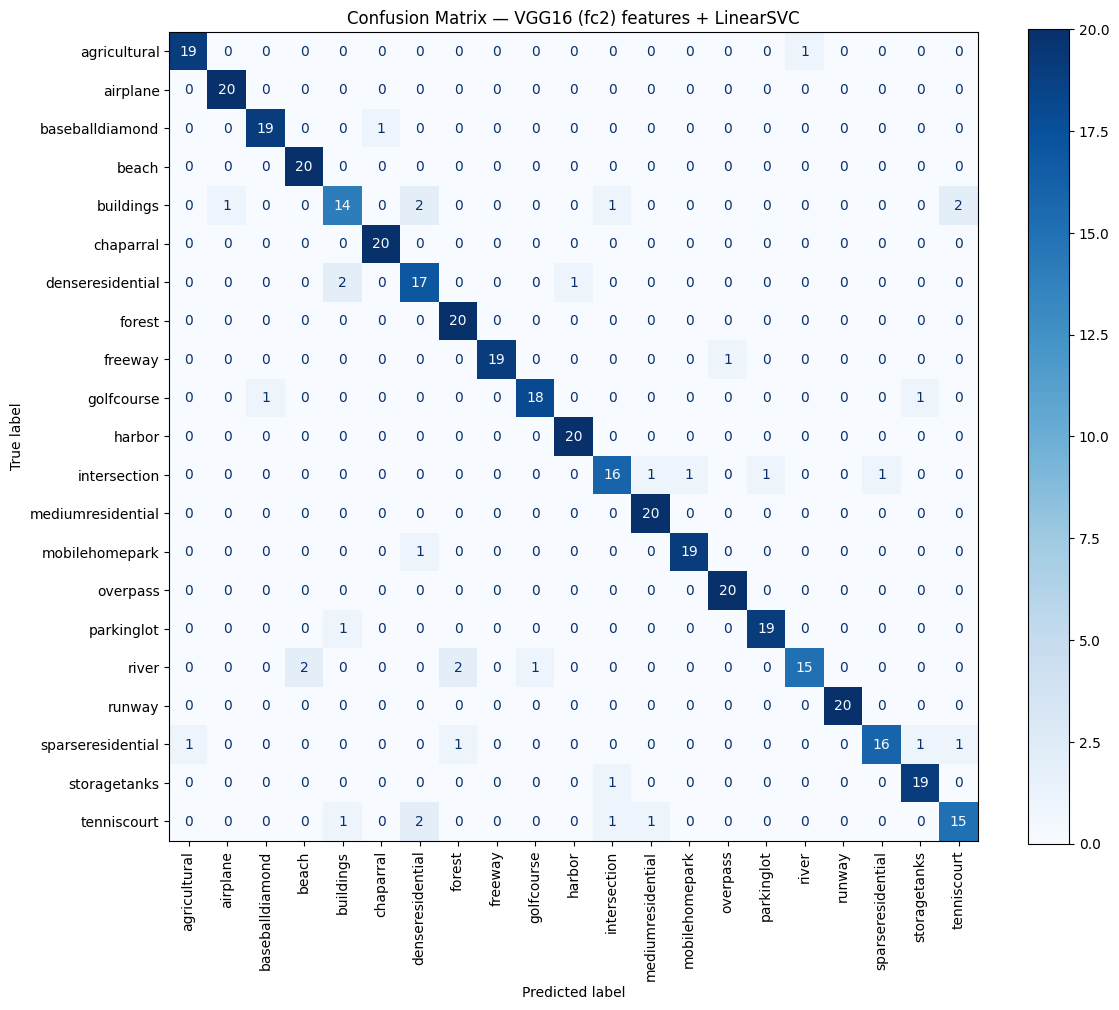

In [18]:
# confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix — VGG16 (fc2) features + LinearSVC")
plt.tight_layout()
plt.show()

### **Build VGG16 feature extractor - Part 2**

In [10]:
base = VGG16(weights='imagenet', include_top=False) 
cnn_layer_name = 'block5_conv3' 
feature_extractor = Model(inputs=base.input, outputs=base.get_layer(cnn_layer_name).output)
feature_extractor.trainable = False

58889256/58889256 [==============================] - 2s 0us/step


In [12]:
def extract_cnn_descriptors(paths, batch_size=BATCH_SIZE):
    all_descriptors = []
    image_descriptors_list = []
    
    n = len(paths)
    for i in tqdm(range(0, n, batch_size), desc="Extracting CNN features"):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            try:
                batch_imgs.append(load_and_preprocess(p)[0])
            except:
                batch_imgs.append(np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.float32))
        batch_array = np.stack(batch_imgs, axis=0)
        feats = feature_extractor.predict(batch_array, verbose=0)  
        B,H,W,C = feats.shape
        for b in range(B):
            descriptors = feats[b].reshape(-1, C)
            all_descriptors.append(descriptors)
            image_descriptors_list.append(descriptors)
    all_descriptors = np.vstack(all_descriptors)
    return all_descriptors, image_descriptors_list

In [26]:
# extract descriptors
all_descriptors, image_descriptors_list = extract_cnn_descriptors(train_images)

Extracting CNN features: 100%|██████████| 53/53 [04:28<00:00,  5.08s/it]


In [27]:
# k-means
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, verbose=1)
kmeans.fit(all_descriptors)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Initialization complete
Iteration 0, inertia 2536249344.0.
Iteration 1, inertia 2138700032.0.
Iteration 2, inertia 2084589696.0.
Iteration 3, inertia 2063834368.0.
Iteration 4, inertia 2052482816.0.
Iteration 5, inertia 2045064448.0.
Iteration 6, inertia 2039744000.0.
Iteration 7, inertia 2035644160.0.
Iteration 8, inertia 2032603264.0.
Iteration 9, inertia 2030310144.0.
Iteration 10, inertia 2028514560.0.
Iteration 11, inertia 2027196928.0.
Iteration 12, inertia 2026217728.0.
Iteration 13, inertia 2025403520.0.
Iteration 14, inertia 2024675840.0.
Iteration 15, inertia 2024017024.0.
Iteration 16, inertia 2023405312.0.
Iteration 17, inertia 2022852096.0.
Iteration 18, inertia 2022260096.0.
Iteration 19, inertia 2021671296.0.
Iteration 20, inertia 2021147008.0.
Iteration 21, inertia 2020641024.0.
Iteration 22, inertia 2020189056.0.
Iteration 23, inertia 2019859840.0.
Iteration 24, inertia 2019604608.0.
Iteration 25, inertia 2019367424.0.
Iteration 26, inertia 2019137152.0.
Iteration 27, 

KMeans(n_clusters=300, random_state=42, verbose=1)

In [28]:
# histograms of visual words
def build_histograms(descriptor_list, kmeans_model):
    histograms = []
    for descriptors in descriptor_list:
        words = kmeans_model.predict(descriptors)
        hist, _ = np.histogram(words, bins=np.arange(NUM_CLUSTERS+1))
        hist = hist.astype(np.float32)
        hist = hist / np.linalg.norm(hist)  # normalize histogram
        histograms.append(hist)
    return np.vstack(histograms)

In [29]:
X_train_bovw = build_histograms(image_descriptors_list, kmeans)

In [30]:
_, test_descriptors_list = extract_cnn_descriptors(test_images)
X_test_bovw = build_histograms(test_descriptors_list, kmeans)

Extracting CNN features: 100%|██████████| 14/14 [01:08<00:00,  4.90s/it]


In [31]:
# encode labels
le = LabelEncoder()
le.fit(train_labels + test_labels)
y_train = le.transform(train_labels)
y_test = le.transform(test_labels)

In [40]:
class_names = le.classes_

In [34]:
# SVM
svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train_bovw, y_train)

SVC(kernel='linear')

In [35]:
y_pred = svm.predict(X_test_bovw)
accuracy = np.mean(y_pred == y_test)
print(f"BoVW + SVM Accuracy: {accuracy:.4f}")

BoVW + SVM Accuracy: 0.8738


In [41]:
print("classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

classification report:
                   precision    recall  f1-score   support

     agricultural     0.9500    0.9500    0.9500        20
         airplane     0.9412    0.8000    0.8649        20
  baseballdiamond     0.8571    0.9000    0.8780        20
            beach     0.8333    1.0000    0.9091        20
        buildings     0.8235    0.7000    0.7568        20
        chaparral     0.9524    1.0000    0.9756        20
 denseresidential     0.7143    0.7500    0.7317        20
           forest     0.8571    0.9000    0.8780        20
          freeway     0.9474    0.9000    0.9231        20
       golfcourse     0.9048    0.9500    0.9268        20
           harbor     1.0000    1.0000    1.0000        20
     intersection     0.8000    0.8000    0.8000        20
mediumresidential     0.6923    0.9000    0.7826        20
   mobilehomepark     0.8947    0.8500    0.8718        20
         overpass     1.0000    0.9500    0.9744        20
       parkinglot     1.0000    

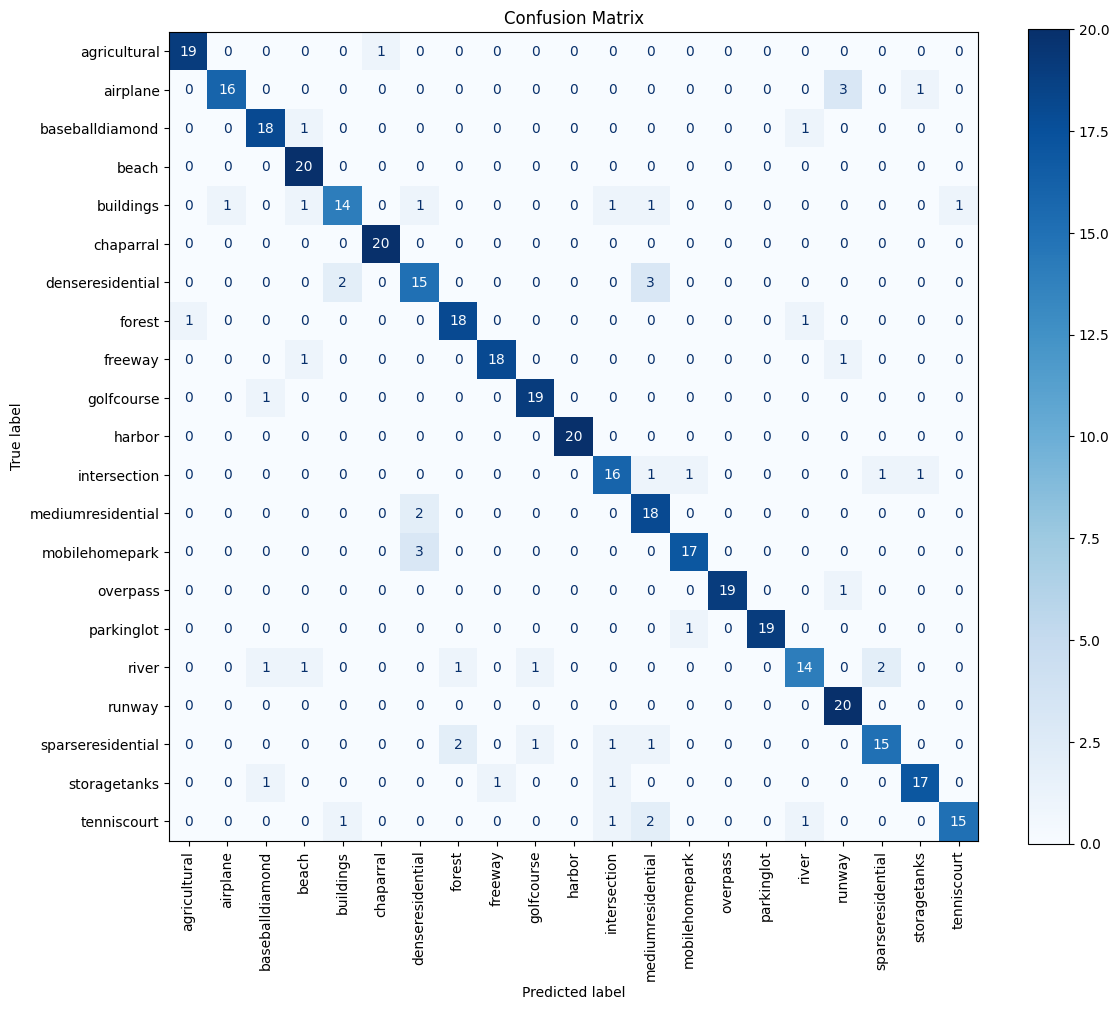

In [43]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()